In [1]:
import numpy as np
import matplotlib.pyplot as plt
import zarr
import os
import glob

import os
import sys

sys.path.append(os.path.abspath(".."))

from src import get_params as gp

plt.style.use('../../my_style.mplstyle')


path = r"/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5/seed*.zarr"

Ps = []
CPs = []

for seed in glob.glob(path):
    polar_path = os.path.join(seed, 'local_polar.zarr')
    center_polar_path = os.path.join(seed, 'center_polar.zarr')
    polar_zarr = zarr.open(polar_path, mode = 'r')
    center_polar_zarr = zarr.open(center_polar_path, mode = 'r')
    polar_orders = polar_zarr[:]
    center_polar_orders = center_polar_zarr[:]

    Ps.append(polar_orders)
    CPs.append(center_polar_orders)

Ps_array = np.array(Ps)
CPs_array = np.array(CPs)

Cs = []
CCs = []

for seed in glob.glob(path):
    counts_path = os.path.join(seed, 'counts.zarr')
    center_counts_path = os.path.join(seed, 'center_counts.zarr')
    counts_zarr = zarr.open(counts_path, mode = 'r')
    center_counts_zarr = zarr.open(center_counts_path, mode = 'r')
    counts = counts_zarr[:]
    center_counts = center_counts_zarr[:]

    Cs.append(counts)
    CCs.append(center_counts)

Cs_array = np.array(Cs)
CCs_array = np.array(CCs)

params = gp.get_params("/Volumes/My Passport/Sasaki/MTCargoSim/MTC/P0.5_A0.5/seed1.zarr")

pf = params['packing_fraction']
L = params['box_size']
r_int = params['r_int']
N=int(pf*L*L/ (np.pi * r_int**2))
print(N)

4074


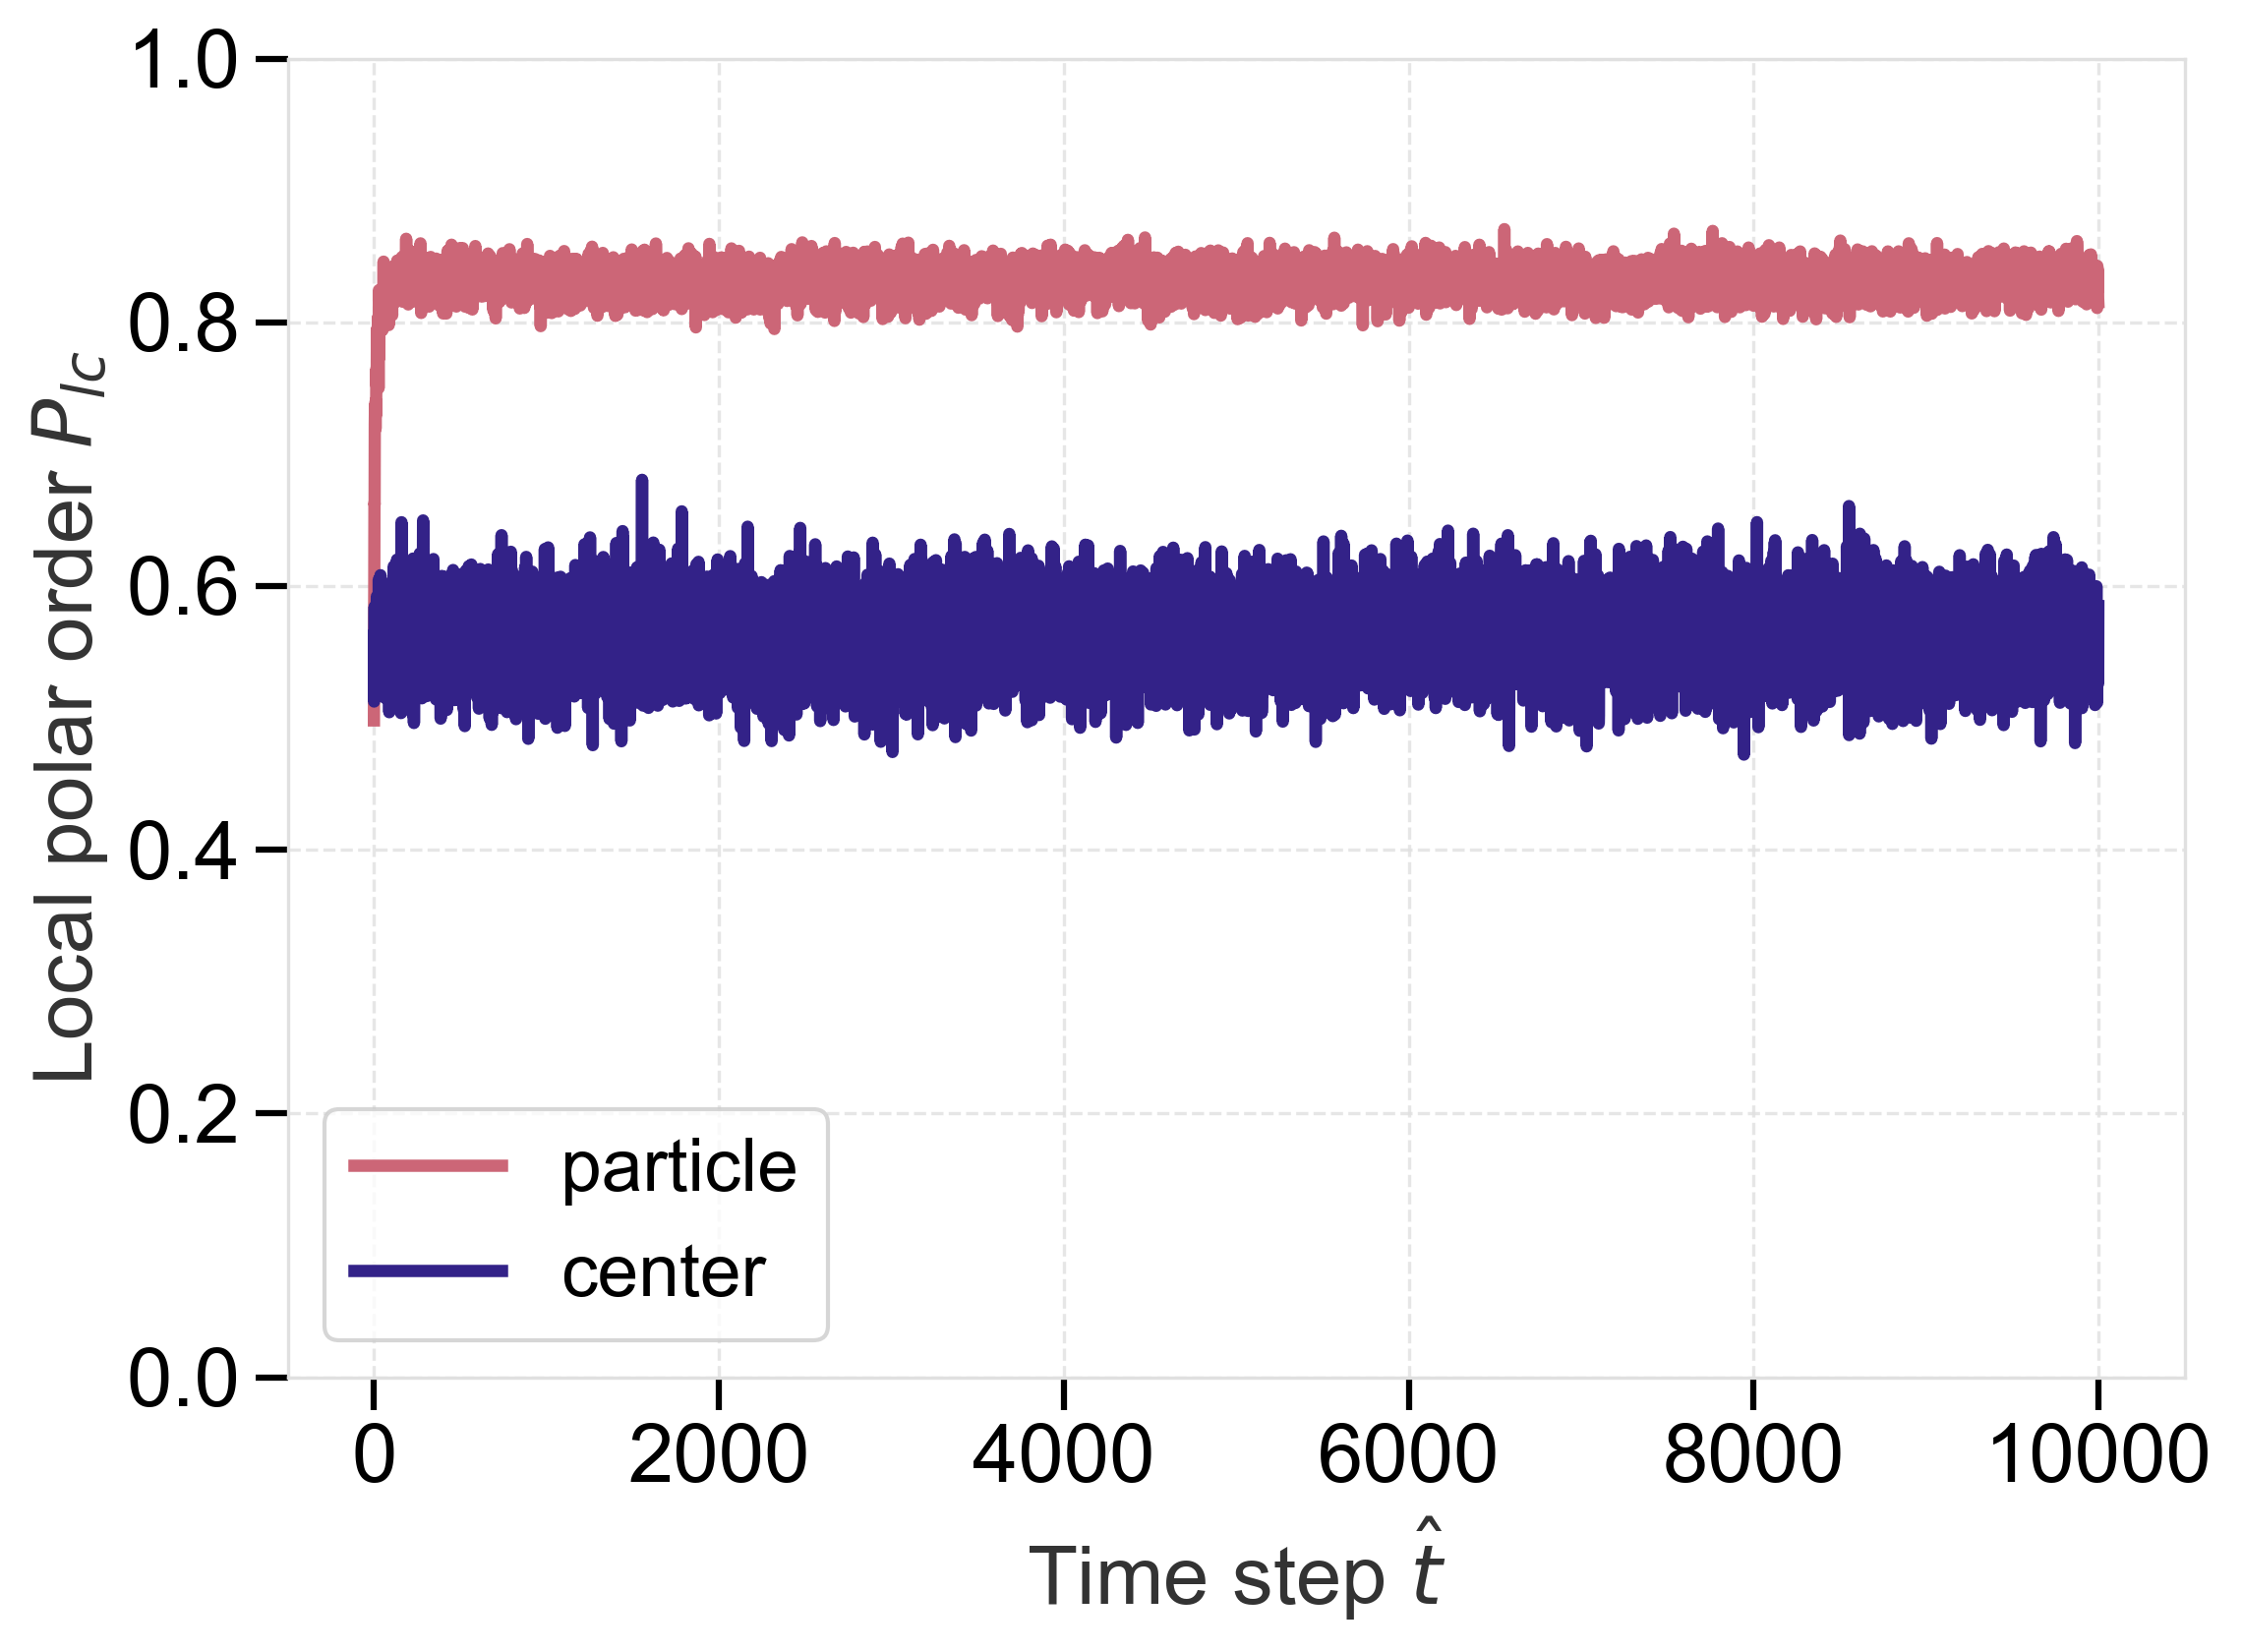

In [7]:
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots()

t = np.arange(0, Ps_array.shape[1], 1)

Pmean = np.mean(Ps_array, axis = 0)
CPmean = np.mean(CPs_array, axis = 0)

Pstd = np.std(Ps_array, axis = 0)
CPstd = np.std(CPs_array, axis = 0)

ax.plot(t, Pmean, color = style_colors[0], label = 'particle' )
ax.plot(t, CPmean, color = style_colors[1], label = 'center')

#ax1.fill_between(t, Pmean-Pstd, Pmean+Pstd, alpha= 0.2, color = style_colors[0])
#ax2.fill_between(t, Cmean/N-Cstd/N, Cmean/N+Cstd/N, alpha= 0.2, color = style_colors[1])

ax.set(
    ylim = (0.0, 1.0),
    xlabel = 'Time step $\hat{t}$'
     )
ax.set_ylabel(ylabel = 'Local polar order $P_{lc}$')
ax.legend()

cd=os.getcwd()

fig.savefig(f"{cd}/figure/Plc.png")
fig.savefig(f"{cd}/figure/Plc.pdf")


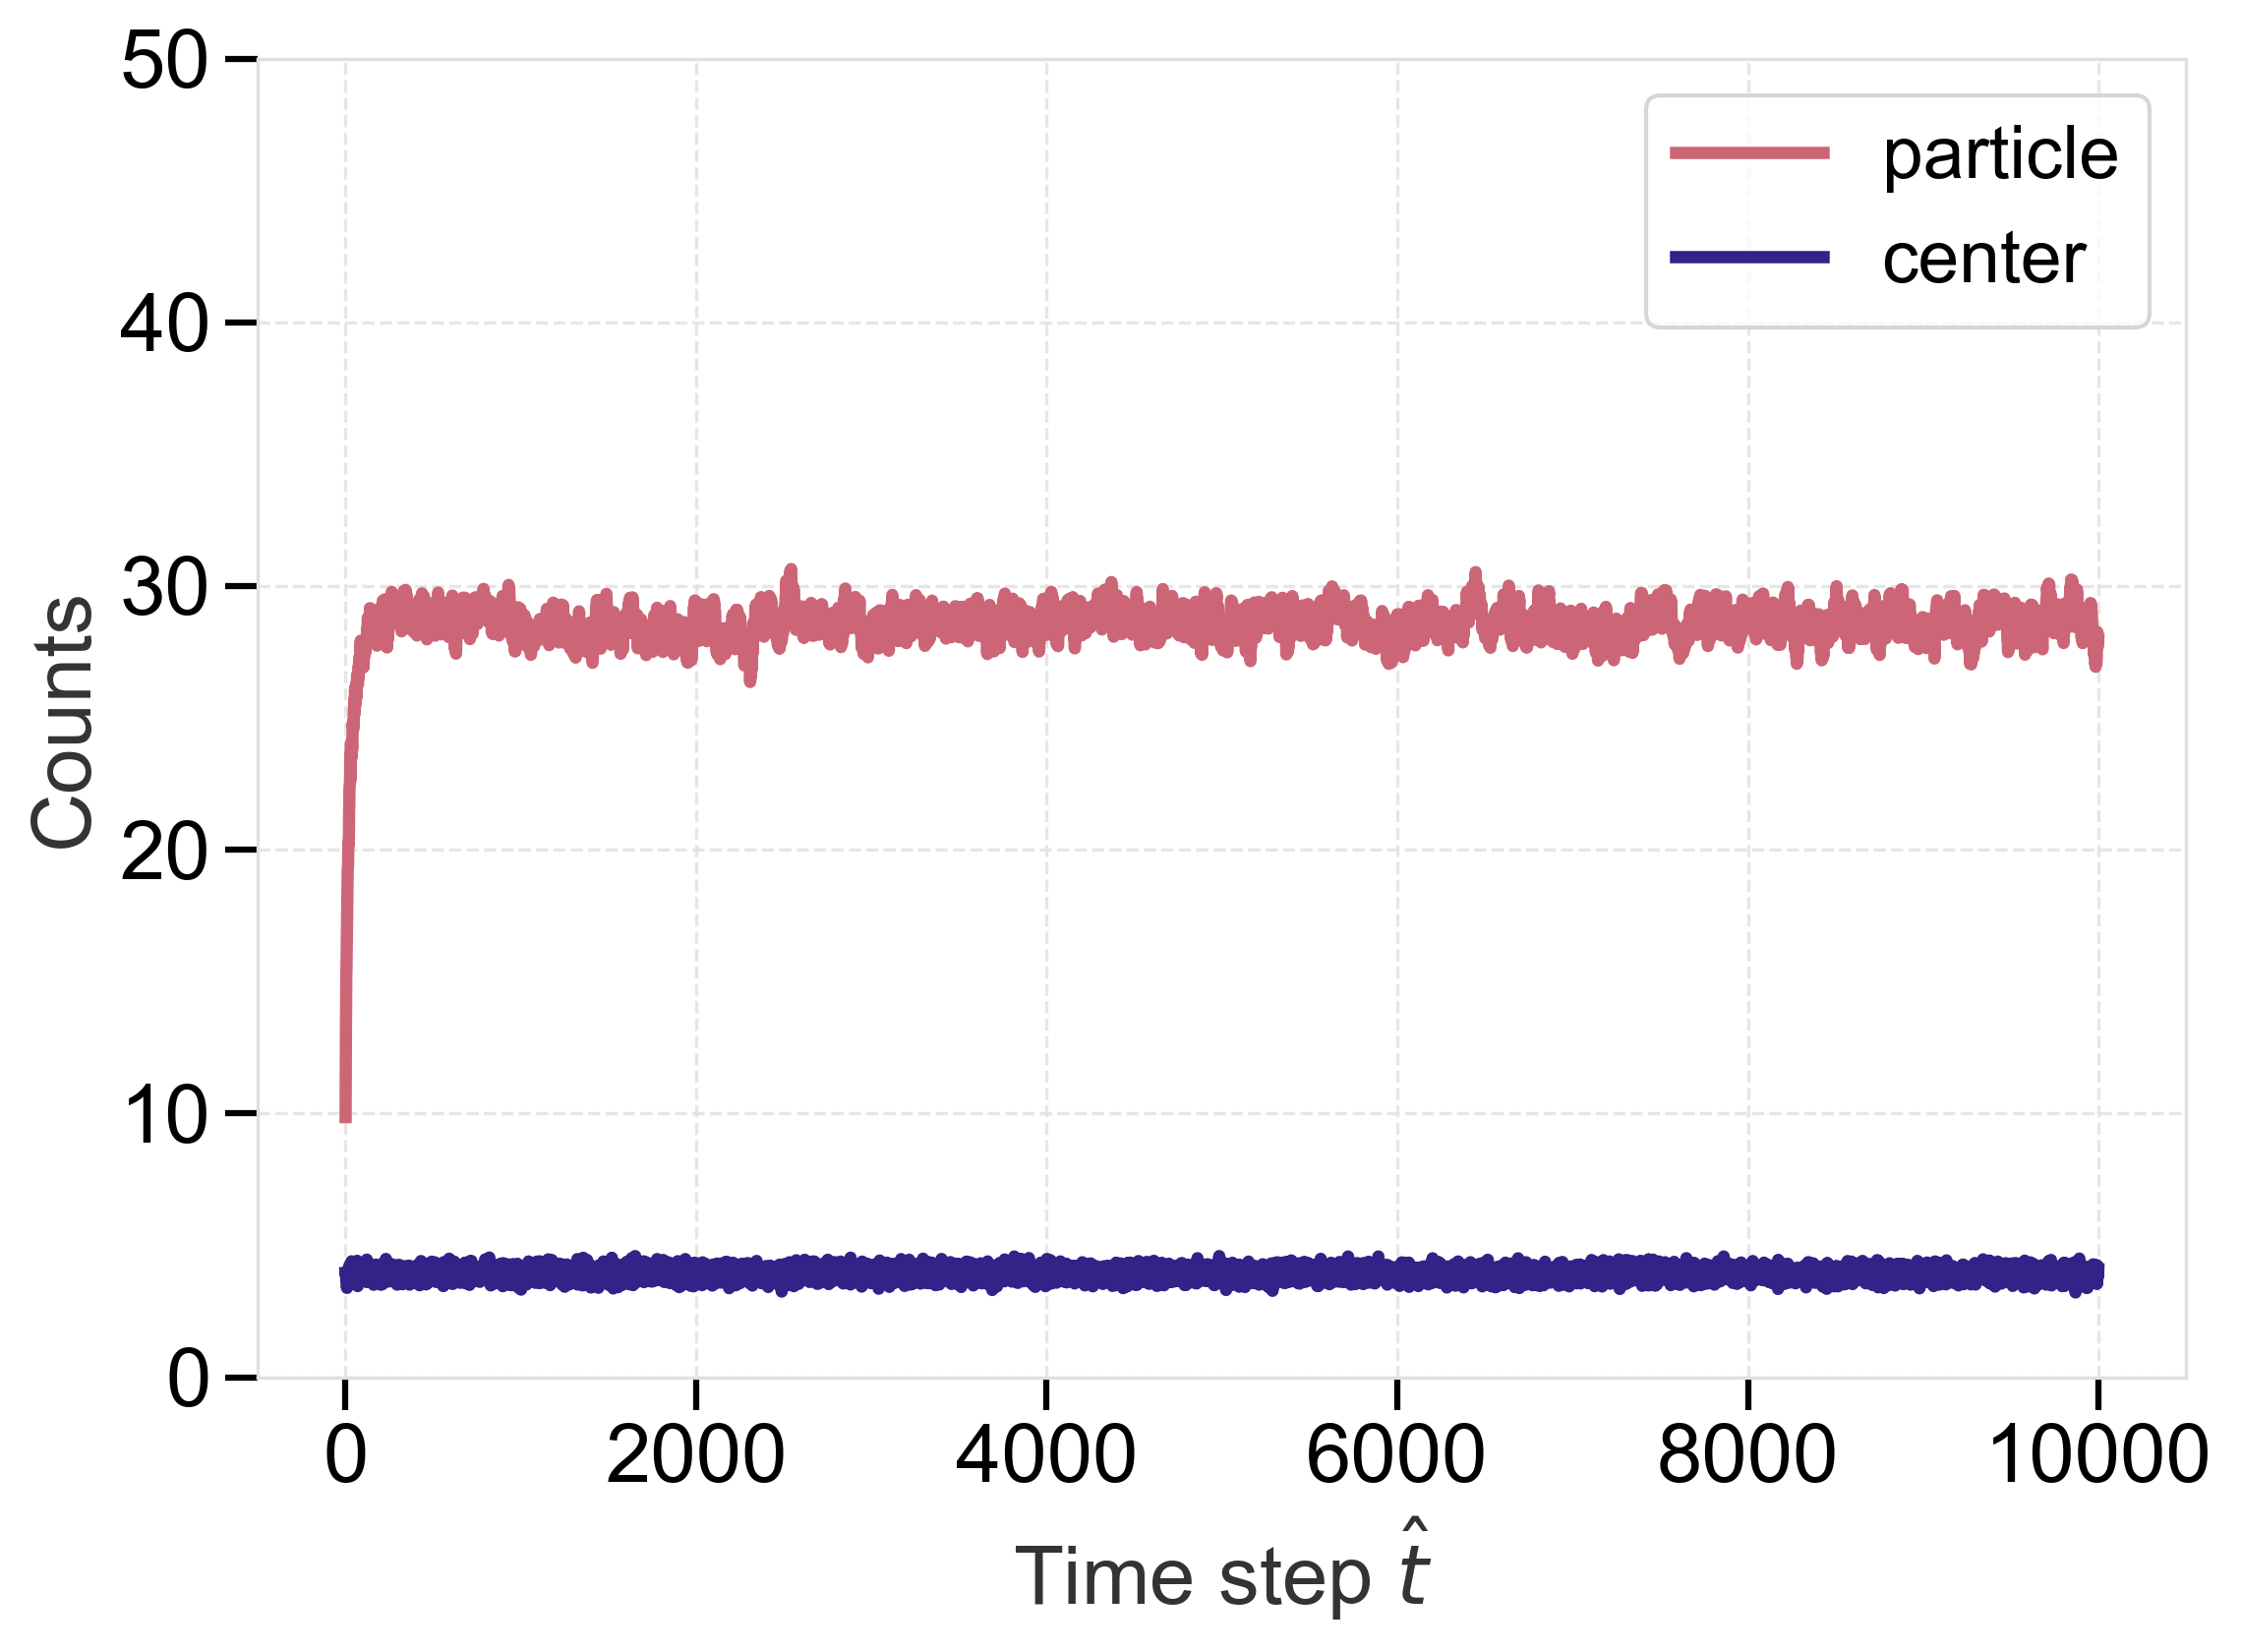

In [9]:
style_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

fig, ax = plt.subplots()

t = np.arange(0, Cs_array.shape[1], 1)

Cmean = np.mean(Cs_array, axis = 0)
CCmean = np.mean(CCs_array, axis = 0)

Cstd = np.std(Cs_array, axis = 0)
CCstd = np.std(CCs_array, axis = 0)


ax.plot(t, Cmean, color = style_colors[0], label = 'particle' )
ax.plot(t, CCmean, color = style_colors[1], label = 'center')

#ax1.fill_between(t, Pmean-Pstd, Pmean+Pstd, alpha= 0.2, color = style_colors[0])
#ax2.fill_between(t, Cmean/N-Cstd/N, Cmean/N+Cstd/N, alpha= 0.2, color = style_colors[1])

ax.set(
    ylim = (0.0, 50),
    xlabel = 'Time step $\hat{t}$'
    )
ax.set_ylabel(ylabel = 'Counts')

ax.legend()

cd=os.getcwd()

fig.savefig(f"{cd}/figure/Clc.png")
fig.savefig(f"{cd}/figure/Clc.pdf")
